# Failure Prediction Models

This notebook trains and compares the models used in the failure prediction part of the project. The objective is to predict exam performance and identify students who may be at risk.

The workflow covers preprocessing, baseline training, tuned models, and a final comparison of the results.


## 1. Data loading and preprocessing

The dataset is first cleaned and transformed into a numerical format suitable for machine learning models.

The preprocessing steps are:

- removal of the `id` column;
- duplicate removal;
- missing value imputation;
- encoding of binary, ordinal and nominal variables;
- creation of two feature sets:
  - a selected feature set based on feature selection;
  - a full feature set containing all available variables.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(r"student_dataset/student_failure/train.csv")

df_ml = df.copy()

# Remove identifier column
if "id" in df_ml.columns:
    df_ml = df_ml.drop(columns=["id"])

# Remove duplicated rows
n_before = len(df_ml)
df_ml = df_ml.drop_duplicates()
print(f"Duplicated rows removed: {n_before - len(df_ml)}")

# Handle missing values
num_cols = df_ml.select_dtypes(include=np.number).columns
cat_cols = df_ml.select_dtypes(include="object").columns

df_ml[num_cols] = df_ml[num_cols].fillna(df_ml[num_cols].mean())
df_ml[cat_cols] = df_ml[cat_cols].fillna("unknown")

# Binary encoding
df_ml["genre"] = df_ml["genre"].map({"male": 0, "female": 1}).fillna(0)
df_ml["accès_internet"] = df_ml["accès_internet"].map({"yes": 1, "no": 0}).fillna(0)

# Ordinal encoding
df_ml["qualité_sommeil"] = df_ml["qualité_sommeil"].map({
    "poor": 0,
    "average": 1,
    "good": 2,
    "excellent": 3
}).fillna(1)

df_ml["évaluation_établissement"] = df_ml["évaluation_établissement"].map({
    "low": 0,
    "medium": 1,
    "high": 2
}).fillna(1)

df_ml["difficulté_examen"] = df_ml["difficulté_examen"].map({
    "easy": 0,
    "moderate": 1,
    "hard": 2
}).fillna(1)

# Nominal encoding
df_ml = pd.get_dummies(
    df_ml,
    columns=["diplôme", "méthode_etude"],
    drop_first=True
)

# Convert boolean columns to float
df_ml = df_ml.astype(float)

# =========================================================
# 2. FEATURE SETS
# =========================================================
selected_features = [
    "heures_etude",
    "genre",
    "assiduité_classe",
    "heures_sommeil",
    "qualité_sommeil",
    "évaluation_établissement",
    "accès_internet",
    "diplôme_Engineering",
    "diplôme_Marketing",
    "diplôme_Computer Science"
]

# Keep only available columns
selected_features = [col for col in selected_features if col in df_ml.columns]

X_selected = df_ml[selected_features]
y = df_ml["score_examen"]

X_full = df_ml.drop(columns=["score_examen"])
y_full = df_ml["score_examen"]

print("Selected features:")
print(X_selected.columns.tolist())
print("\nSelected feature set shape:", X_selected.shape)
print("Full feature set shape:", X_full.shape)

Duplicated rows removed: 0


C:\Users\louis\AppData\Local\Temp\ipykernel_22432\273297921.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_ml.select_dtypes(include="object").columns


Selected features:
['heures_etude', 'genre', 'assiduité_classe', 'heures_sommeil', 'qualité_sommeil', 'évaluation_établissement', 'accès_internet', 'diplôme_Engineering', 'diplôme_Marketing', 'diplôme_Computer Science']

Selected feature set shape: (630000, 10)
Full feature set shape: (630000, 22)


## 2. Train/test split and baseline model

The data is split into a training set and a test set.  
The baseline model predicts the average exam score of the training set for every student.

This baseline is useful because it gives a simple reference. A trained model is useful only if it performs better than this naive prediction.

In [11]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# =========================================================
# BASELINE MODEL
# =========================================================
baseline_pred = np.full(len(yf_test), yf_train.mean())

baseline_mae = mean_absolute_error(yf_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(yf_test, baseline_pred))
baseline_r2 = r2_score(yf_test, baseline_pred)

print("===== BASELINE =====")
print(f"MAE  : {baseline_mae:.3f}")
print(f"RMSE : {baseline_rmse:.3f}")
print(f"R²   : {baseline_r2:.3f}")

===== BASELINE =====
MAE  : 15.546
RMSE : 18.897
R²   : -0.000


## 3. Optimized hyperparameters

The hyperparameters were optimized in a separate notebook using a two-step method:

1. **RandomizedSearchCV** to explore a large range of possible hyperparameter values;
2. **GridSearchCV** around the best configuration found during the random search.

The optimization used the validation RMSE as the selection criterion. The optimized values below are then reused to train the final models in this notebook.

| Model | Optimized hyperparameters | Best CV RMSE |
|---|---|---:|
| Ridge Regression | `alpha = 13.303` | 9.861 |
| Decision Tree | `ccp_alpha = 1.289e-06`, `max_depth = 19`, `max_leaf_nodes = 531`, `min_samples_leaf = 54`, `min_samples_split = 23` | 10.419 |
| Random Forest | `n_estimators = 312`, `max_depth = 16`, `max_features = 0.5`, `min_samples_leaf = 17`, `min_samples_split = 2` | 9.943 |

## 4. Random Forest on selected features

A Random Forest is first trained on the selected feature set. This is used to compare the selected feature set with the full feature set and to visualize feature importance.

===== RANDOM FOREST - SELECTED FEATURES =====
MAE  : 7.768
RMSE : 9.778
R²   : 0.732


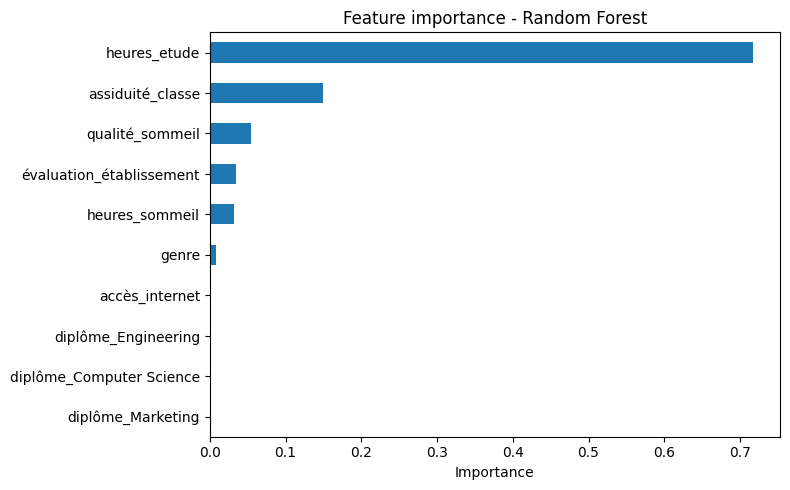

In [3]:
# =========================================================
# RANDOM FOREST ON SELECTED FEATURES
# =========================================================
rf_selected = RandomForestRegressor(
    n_estimators=312,
    max_depth=16,
    max_features=0.5,
    min_samples_leaf=17,
    min_samples_split=2,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_selected.fit(X_train, y_train)
preds_rf_selected = rf_selected.predict(X_test)

mae_rf_selected = mean_absolute_error(y_test, preds_rf_selected)
rmse_rf_selected = np.sqrt(mean_squared_error(y_test, preds_rf_selected))
r2_rf_selected = r2_score(y_test, preds_rf_selected)

print("===== RANDOM FOREST - SELECTED FEATURES =====")
print(f"MAE  : {mae_rf_selected:.3f}")
print(f"RMSE : {rmse_rf_selected:.3f}")
print(f"R²   : {r2_rf_selected:.3f}")

# Feature importance
importances = pd.Series(rf_selected.feature_importances_, index=X_selected.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind="barh")
plt.title("Feature importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 5. Optimized Decision Tree

The Decision Tree is trained with the optimized hyperparameters.  
The goal is to reduce overfitting by limiting the complexity of the tree.

In [4]:
# =========================================================
# OPTIMIZED DECISION TREE
# =========================================================
tree_model = DecisionTreeRegressor(
    ccp_alpha=1.2898495377182665e-06,
    max_depth=19,
    max_leaf_nodes=531,
    min_samples_leaf=54,
    min_samples_split=23,
    random_state=RANDOM_STATE
)

tree_model.fit(Xf_train, yf_train)
y_pred_tree = tree_model.predict(Xf_test)

mae_tree = mean_absolute_error(yf_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(yf_test, y_pred_tree))
r2_tree = r2_score(yf_test, y_pred_tree)

print("===== OPTIMIZED DECISION TREE =====")
print(f"MAE  : {mae_tree:.3f}")
print(f"RMSE : {rmse_tree:.3f}")
print(f"R²   : {r2_tree:.3f}")

===== OPTIMIZED DECISION TREE =====
MAE  : 8.121
RMSE : 10.196
R²   : 0.709


## 6. Optimized Ridge Regression

Ridge Regression is trained inside a pipeline with a `StandardScaler`.  
Scaling is useful for Ridge Regression because the model is sensitive to the scale of the input variables.

The optimized value of the regularization parameter is:

\[
lpha = 13.303
\]

In [5]:
# =========================================================
# OPTIMIZED RIDGE REGRESSION
# =========================================================
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=13.3032451015229))
])

ridge_model.fit(Xf_train, yf_train)
y_pred_ridge = ridge_model.predict(Xf_test)

mae_ridge = mean_absolute_error(yf_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(yf_test, y_pred_ridge))
r2_ridge = r2_score(yf_test, y_pred_ridge)

print("===== OPTIMIZED RIDGE REGRESSION =====")
print(f"MAE  : {mae_ridge:.3f}")
print(f"RMSE : {rmse_ridge:.3f}")
print(f"R²   : {r2_ridge:.3f}")

===== OPTIMIZED RIDGE REGRESSION =====
MAE  : 7.359
RMSE : 9.287
R²   : 0.758


## 7. Optimized Random Forest on full features

The Random Forest is trained with the optimized hyperparameters.  
This model is more complex than Ridge Regression and can capture non-linear relationships between variables.

In [6]:
# =========================================================
# OPTIMIZED RANDOM FOREST - FULL FEATURES
# =========================================================
rf_full = RandomForestRegressor(
    n_estimators=312,
    max_depth=16,
    max_features=0.5,
    min_samples_leaf=17,
    min_samples_split=2,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_full.fit(Xf_train, yf_train)
preds_rf_full = rf_full.predict(Xf_test)

mae_rf_full = mean_absolute_error(yf_test, preds_rf_full)
rmse_rf_full = np.sqrt(mean_squared_error(yf_test, preds_rf_full))
r2_rf_full = r2_score(yf_test, preds_rf_full)

print("===== OPTIMIZED RANDOM FOREST - FULL FEATURES =====")
print(f"MAE  : {mae_rf_full:.3f}")
print(f"RMSE : {rmse_rf_full:.3f}")
print(f"R²   : {r2_rf_full:.3f}")

===== OPTIMIZED RANDOM FOREST - FULL FEATURES =====
MAE  : 7.496
RMSE : 9.444
R²   : 0.750


## 8. Deep Learning model

A simple Multi-Layer Perceptron is also trained.  
The data is scaled before training because neural networks are sensitive to the scale of the input variables.

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =========================================================
# SCALING FOR DEEP LEARNING
# =========================================================
dl_scaler = StandardScaler()
X_train_scaled = dl_scaler.fit_transform(Xf_train)
X_test_scaled = dl_scaler.transform(Xf_test)

# =========================================================
# MLP MODEL
# =========================================================
model_dl = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model_dl.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = model_dl.fit(
    X_train_scaled, yf_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    verbose=1
)

preds_dl = model_dl.predict(X_test_scaled).flatten()

mae_dl = mean_absolute_error(yf_test, preds_dl)
rmse_dl = np.sqrt(mean_squared_error(yf_test, preds_dl))
r2_dl = r2_score(yf_test, preds_dl)

print("===== DEEP LEARNING MLP =====")
print(f"MAE  : {mae_dl:.3f}")
print(f"RMSE : {rmse_dl:.3f}")
print(f"R²   : {r2_dl:.3f}")

Epoch 1/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 587.4656 - mae: 15.5810 - val_loss: 100.7496 - val_mae: 7.9833
Epoch 2/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 95.8546 - mae: 7.7863 - val_loss: 93.6709 - val_mae: 7.6841
Epoch 3/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 91.9920 - mae: 7.6251 - val_loss: 91.4067 - val_mae: 7.5909
Epoch 4/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 90.3016 - mae: 7.5523 - val_loss: 90.2728 - val_mae: 7.5428
Epoch 5/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 89.1493 - mae: 7.5037 - val_loss: 89.6248 - val_mae: 7.5176
Epoch 6/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 88.2783 - mae: 7.4651 - val_loss: 88.4320 - val_mae: 7.4634
Epoch 7/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 87.5815 - mae: 7.4334 - val_loss: 87.8225 - val_mae: 7.4370
Epoch 8/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 87.0878 - mae: 7.4137 - val_loss: 87.4100 - val_mae: 7.4146
Epoch 9/20
1575/1575 

## 9. Final model comparison

The final models are compared using three metrics:

- **MAE**: average absolute error;
- **RMSE**: error metric that gives more weight to large errors;
- **R²**: proportion of variance explained by the model.

The best model is the one with the lowest MAE/RMSE and the highest R².

===== FINAL COMPARISON =====


,Model,MAE,RMSE,R2
4,Ridge Regression (Optimized),7.359403,9.286525,0.758497
5,Deep Learning (MLP),7.372373,9.292797,0.758171
3,"Random Forest (Full, Optimized)",7.495775,9.444160,0.750229
2,"Random Forest (Selected, Optimized)",7.767742,9.778438,0.732235
1,Decision Tree (Optimized),8.121476,10.195731,0.708893
0,Baseline,15.545894,18.897375,-0.000042


<Figure size 1000x600 with 0 Axes>

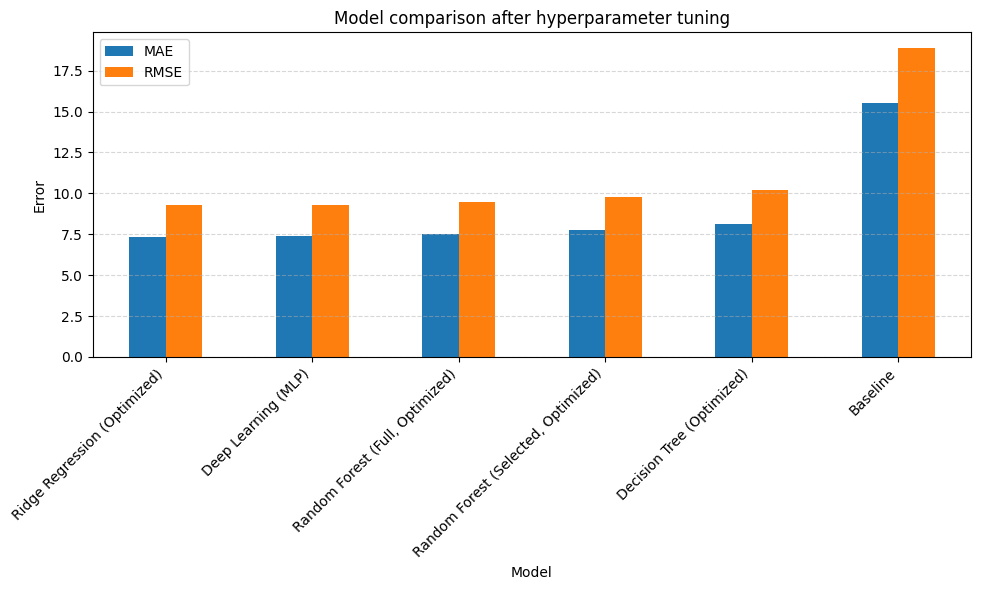

In [8]:
# =========================================================
# FINAL COMPARISON
# =========================================================
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Decision Tree (Optimized)",
        "Random Forest (Selected, Optimized)",
        "Random Forest (Full, Optimized)",
        "Ridge Regression (Optimized)",
        "Deep Learning (MLP)"
    ],
    "MAE": [
        baseline_mae,
        mae_tree,
        mae_rf_selected,
        mae_rf_full,
        mae_ridge,
        mae_dl
    ],
    "RMSE": [
        baseline_rmse,
        rmse_tree,
        rmse_rf_selected,
        rmse_rf_full,
        rmse_ridge,
        rmse_dl
    ],
    "R2": [
        baseline_r2,
        r2_tree,
        r2_rf_selected,
        r2_rf_full,
        r2_ridge,
        r2_dl
    ]
})

results = results.sort_values(by="RMSE")

print("===== FINAL COMPARISON =====")
display(results)

# Plot only MAE and RMSE to keep the graph readable
plot_df = results.set_index("Model")[["MAE", "RMSE"]]

plt.figure(figsize=(10, 6))
plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model comparison after hyperparameter tuning")
plt.ylabel("Error")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Analysis plots for the best model

Ridge Regression was selected as the best model because it obtained the lowest error while remaining simple and stable.

The following plots are used to analyse its predictions:

- predicted score versus real score;
- distribution of prediction errors.

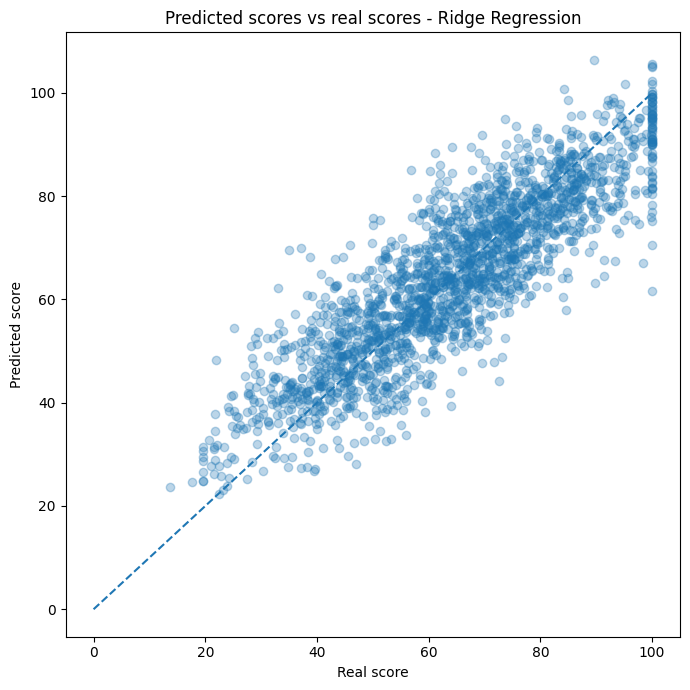

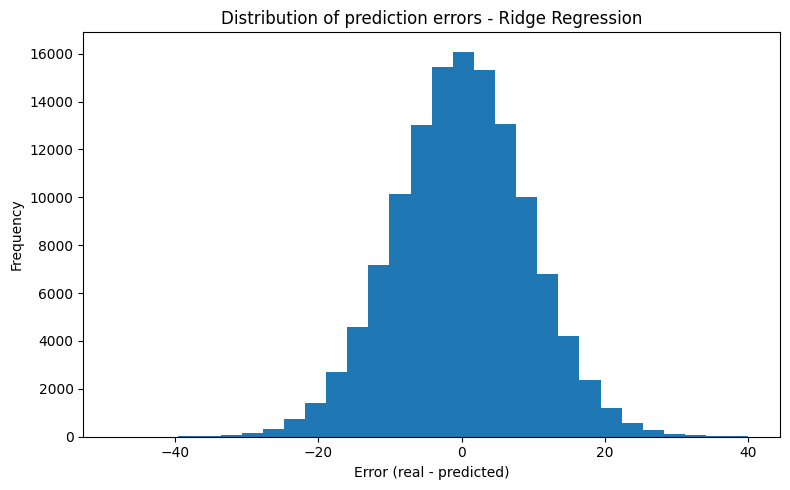

In [9]:
# =========================================================
# PREDICTED VS REAL SCORES - RIDGE REGRESSION
# =========================================================
sample_idx = np.random.choice(len(yf_test), size=2000, replace=False) if len(yf_test) > 2000 else np.arange(len(yf_test))

plt.figure(figsize=(7, 7))
plt.scatter(yf_test.iloc[sample_idx], y_pred_ridge[sample_idx], alpha=0.3)
plt.xlabel("Real score")
plt.ylabel("Predicted score")
plt.title("Predicted scores vs real scores - Ridge Regression")
plt.plot([0, 100], [0, 100], linestyle="--")
plt.tight_layout()
plt.show()

# =========================================================
# ERROR DISTRIBUTION - RIDGE REGRESSION
# =========================================================
errors_ridge = yf_test - y_pred_ridge

plt.figure(figsize=(8, 5))
plt.hist(errors_ridge, bins=30)
plt.title("Distribution of prediction errors - Ridge Regression")
plt.xlabel("Error (real - predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()